In [1]:
# ! pip install astroML

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import uniform
from scipy import optimize
from astroML import stats as astroMLstats
from sklearn.neighbors import KernelDensity
import scipy.integrate as spi
import sympy as sp

In [3]:
def f(a):
    return np.sqrt((1+np.sqrt(1-a**2))/2)

In [4]:
def M_irr(M, a):
    return M*f(a)

In [5]:
counts = 10000
vec_M = np.random.normal(1, 0.02, size=counts)
vec_a = np.random.uniform(0, 1, size=counts)

In [6]:
vec_M_irr = M_irr(vec_M, vec_a)
vec_f = f(vec_a)

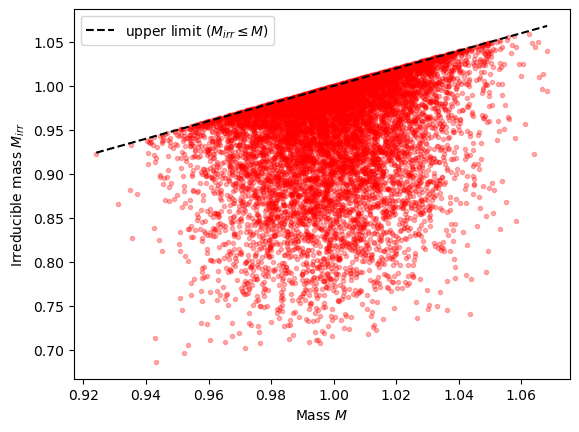

In [7]:
plt.scatter(vec_M, vec_M_irr, color="r", marker=".", alpha=0.3)
plt.plot(np.sort(vec_M), np.sort(vec_M), "--k", label=r"upper limit $(M_{irr} \leq M)$")
plt.xlabel(r"Mass $M$")
plt.ylabel(r"Irreducible mass $M_{irr}$")
plt.legend()
plt.show()

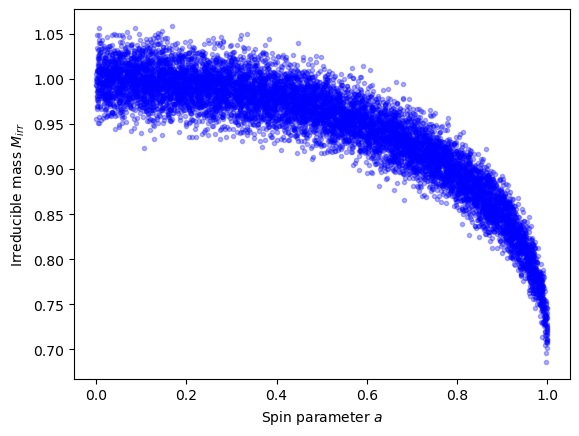

In [8]:
plt.scatter(vec_a, vec_M_irr, color="b", marker=".", alpha=0.3)
plt.xlabel(r"Spin parameter $a$")
plt.ylabel(r"Irreducible mass $M_{irr}$")
plt.show()

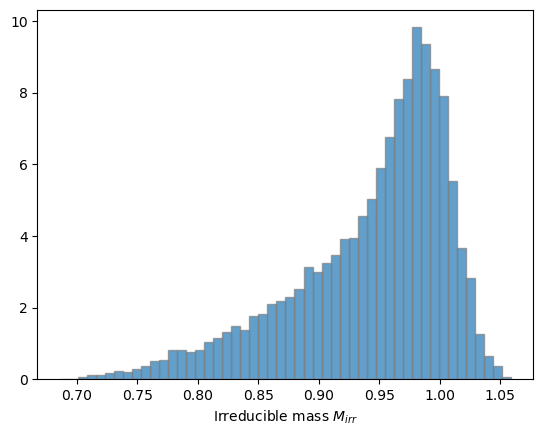

In [9]:
_,_,_=plt.hist(vec_M_irr, bins=50, density=True, edgecolor="gray", alpha=0.7)
plt.xlabel(r"Irreducible mass $M_{irr}$")
plt.show()

In [10]:
# making variable-width bin sizes that have the same number of objects in each bin.
bins100 = np.append(np.sort(vec_M_irr)[::100], np.max(vec_M_irr))
bins500 = np.append(np.sort(vec_M_irr)[::500], np.max(vec_M_irr))

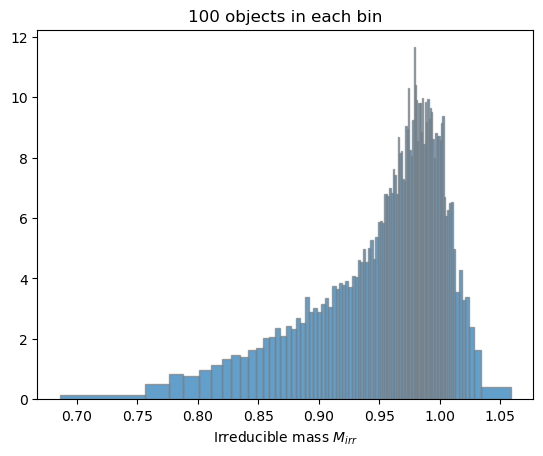

In [11]:
_,_,_=plt.hist(vec_M_irr, bins=bins100, density=True, edgecolor="gray", alpha=0.7)
plt.xlabel(r"Irreducible mass $M_{irr}$")
plt.title("100 objects in each bin")
plt.show()

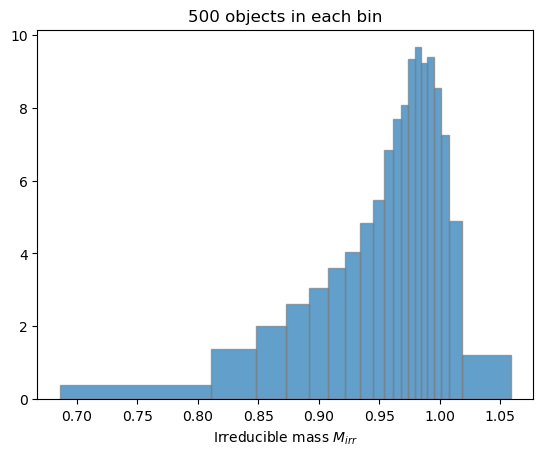

In [12]:
_,_,_=plt.hist(vec_M_irr, bins=bins500, density=True, edgecolor="gray", alpha=0.7)
plt.xlabel(r"Irreducible mass $M_{irr}$")
plt.title("500 objects in each bin")
plt.show()

In [13]:
# define a KDE
def kde_sklearn(data, bandwidth, kernel, grid):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel = kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(grid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

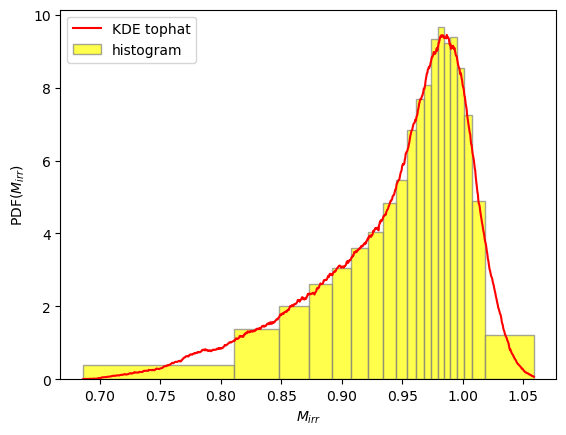

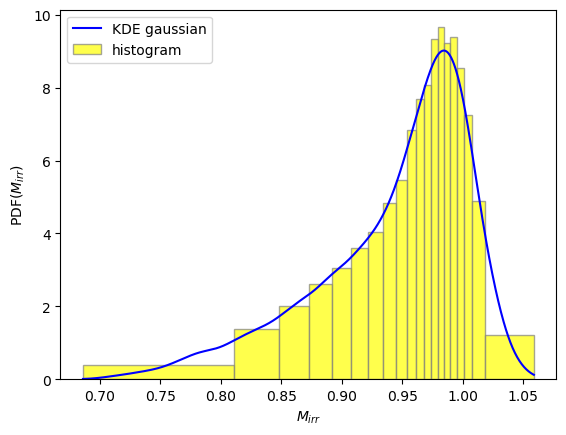

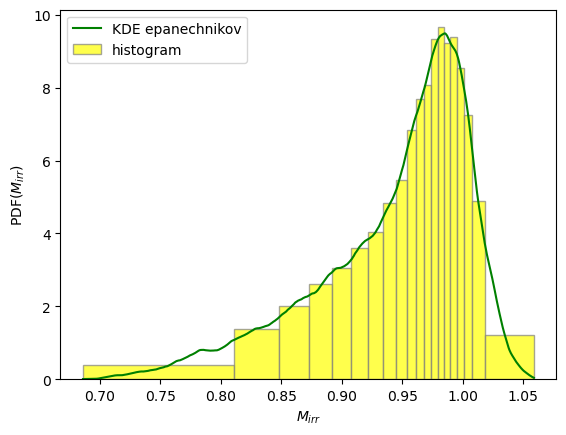

In [14]:
grid = np.linspace(vec_M_irr.min(), vec_M_irr.max(), 1000)
PDF_gauss = kde_sklearn(vec_M_irr, 0.01, "gaussian", grid)
PDF_tophat = kde_sklearn(vec_M_irr, 0.01, "tophat", grid)
PDF_epanechnikov = kde_sklearn(vec_M_irr, 0.01, "epanechnikov", grid)

plt.plot(grid, PDF_tophat, "-r", label="KDE tophat")
plt.hist(vec_M_irr, bins=bins500, density=True, edgecolor="gray", color="yellow", alpha=0.7, label="histogram")
plt.xlabel(r"$M_{irr}$")
plt.ylabel(r"PDF($M_{irr}$)")
plt.legend(loc="upper left")
plt.show()

plt.plot(grid, PDF_gauss, "-b", label="KDE gaussian")
plt.hist(vec_M_irr, bins=bins500, density=True, edgecolor="gray", color="yellow", alpha=0.7, label="histogram")
plt.xlabel(r"$M_{irr}$")
plt.ylabel(r"PDF($M_{irr}$)")
plt.legend(loc="upper left")
plt.show()

plt.plot(grid, PDF_epanechnikov, "-g", label="KDE epanechnikov")
plt.hist(vec_M_irr, bins=bins500, density=True, edgecolor="gray", color="yellow", alpha=0.7, label="histogram")
plt.xlabel(r"$M_{irr}$")
plt.ylabel(r"PDF($M_{irr}$)")
plt.legend(loc="upper left")
plt.show()

In [15]:
# try some KS tests
# ?stats.ks_2samp

In [16]:
vec_sigma = np.logspace(-5, 5, 1000)
list_M_irr = []
list_M = []
for sigma_i in vec_sigma:
    temp_M = np.random.normal(1, sigma_i, size=counts)
    list_M_irr.append(M_irr(temp_M, vec_a))
    list_M.append(temp_M)

In [17]:
# Suppose we wish to test the null hypothesis that two samples were drawn from the same distribution.
# We choose a confidence level of 95%; that is, we will reject the null hypothesis in favor of the alternative if the p-value is less than 0.05.

vec1_ks = [stats.ks_2samp(M_irr_i, vec_f)[0] for M_irr_i in list_M_irr]
vec2_ks = [stats.ks_2samp(list_M_irr[i], list_M[i])[0] for i in range(len(list_M_irr))]

vec1_p = [stats.ks_2samp(M_irr_i, vec_f)[1] for M_irr_i in list_M_irr]
vec2_p = [stats.ks_2samp(list_M_irr[i], list_M[i])[1] for i in range(len(list_M_irr))]

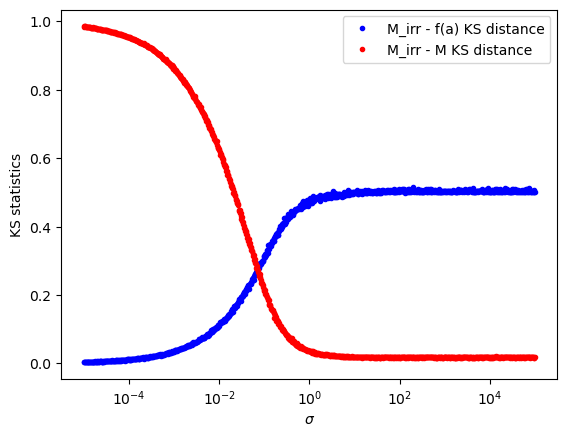

In [18]:
plt.plot(vec_sigma, vec1_ks, '.b', label="M_irr - f(a) KS distance")
plt.plot(vec_sigma, vec2_ks, '.r', label="M_irr - M KS distance")
plt.xscale("log")
plt.xlabel(r"$\sigma$")
plt.ylabel("KS statistics")
plt.legend()
plt.show()

Suppose we wish to test the null hypothesis that two samples were drawn from the same distribution.

We choose a confidence level of 95%; that is, we will reject the null hypothesis in favor of the alternative if the p-value is less than 0.05.

You should find that (i) $M_{irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

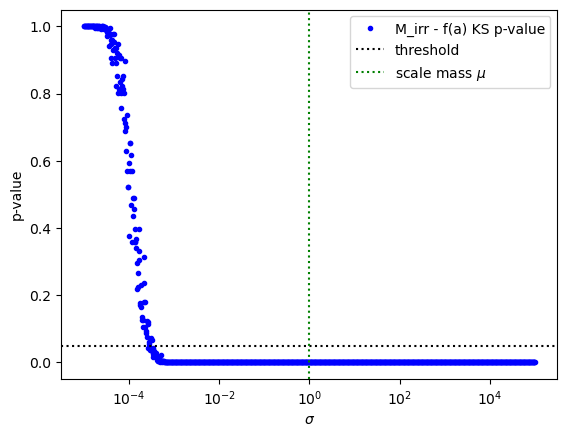

In [19]:
plt.plot(vec_sigma, vec1_p, '.b', label="M_irr - f(a) KS p-value")
plt.axhline(0.05, c='black', ls='dotted', label='threshold')
plt.axvline(1, c='green', ls='dotted', label=r'scale mass $\mu$')
plt.xscale("log")
plt.xlabel(r"$\sigma$")
plt.ylabel("p-value")
plt.legend()
plt.show()

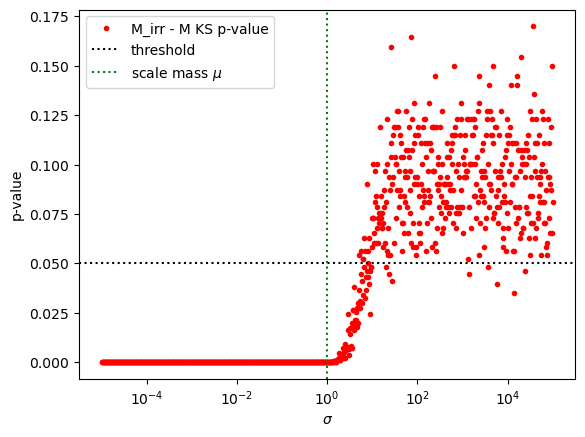

In [20]:
plt.plot(vec_sigma, vec2_p, '.r', label="M_irr - M KS p-value")
plt.axhline(0.05, c='black', ls='dotted', label='threshold')
plt.axvline(1, c='green', ls='dotted', label=r'scale mass $\mu$')
plt.xscale("log")
plt.xlabel(r"$\sigma$")
plt.ylabel("p-value")
plt.legend()
plt.show()

In [21]:
# analyze the pdf of f(a)
def pdf_f(f):
  return 2*(2*f**2-1)/np.sqrt(1-f**2)

In [22]:
grid_f = np.linspace(1/np.sqrt(2), 0.999, 1000)

In [23]:
# check normalization of the pdf
integrale, errore = spi.quad(pdf_f, 1/np.sqrt(2), 1)
print(integrale)

0.9999999999974235


In [24]:
x = sp.Symbol('x')
func = 2*(2*(x**2)-1)/sp.sqrt(1-(x**2))
integrale_definito = sp.integrate(func, (x, 1/sp.sqrt(2), 1))
print(integrale_definito)

1


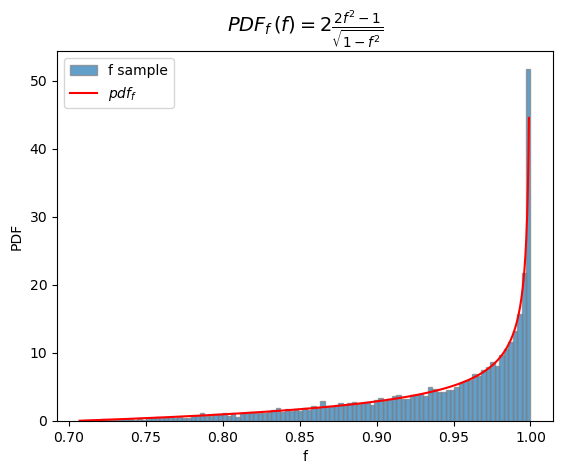

In [25]:
_,_,_=plt.hist(vec_f, bins=100, density=True, edgecolor="gray", alpha=0.7, label="f sample")
plt.plot(grid_f, pdf_f(grid_f), "-r", label=r"$pdf_f$")
plt.title(r'$PDF_f\,(f) = 2\frac{2f^2 - 1}{\sqrt{1 - f^2}}$', fontsize=14)
plt.xlabel("f")
plt.ylabel("PDF")
plt.legend()
plt.show()

In [26]:
# Parameters for the Gaussian
mu = 1
sigma = 0.02

# Define the PDF of y
def f_y(y):
    return 2 * (2 * y**2 - 1) / np.sqrt(1 - y**2)

# Define the PDF of z
def f_z(z):
    integrand = lambda y: (1 / y) * norm.pdf(z / y, loc=mu, scale=sigma) * f_y(y)
    return spi.quad(integrand, 1/np.sqrt(2), 1)[0]

# Evaluate f_z over a range of z values
z_vals = np.linspace(min(vec_M_irr), max(vec_M_irr), 500)
fz_vals = [f_z(z) for z in z_vals]

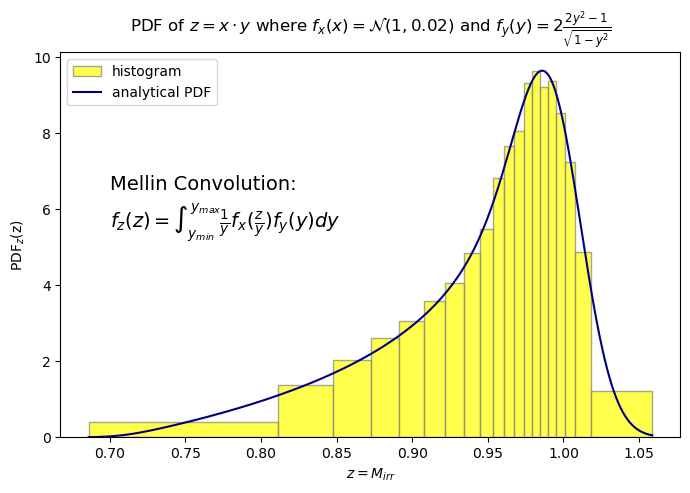

In [28]:
# Plot
plt.figure(figsize=(8, 5))
plt.hist(vec_M_irr, bins=bins500, density=True, edgecolor="gray", color="yellow", alpha=0.7, label="histogram")
plt.plot(z_vals, fz_vals, label='analytical PDF', color='navy')
plt.title(r'PDF of $z = x \cdot y$ where $f_x(x) = \mathcal{N}(1, 0.02)$ and $f_y(y) = 2\frac{2y^2 - 1}{\sqrt{1 - y^2}}$')
plt.text(0.7, 6.5, 'Mellin Convolution:', fontsize=14)
plt.text(0.7, 5.5, r"$f_z(z) = \int_{y_{min}}^{y_{max}}\frac{1}{y}f_x(\frac{z}{y})f_y(y)dy$", fontsize=14)
plt.xlabel(r"$z = M_{irr}$")
plt.ylabel(r'PDF$_z$(z)')
plt.legend(loc='upper left')
plt.show()